In [69]:
import pandas as pd
from keras.optimizers import Adam
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [33]:
dataset = pd.read_csv('titanic_train.csv')

In [34]:
dataset.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [35]:
dataset.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [36]:
dataset.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


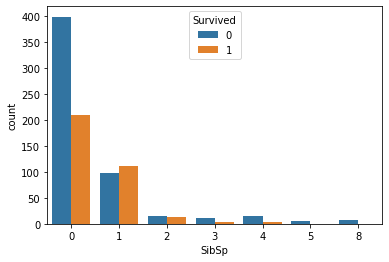

In [37]:
sns.countplot(dataset['SibSp'], data=dataset, hue='Survived')

In [38]:
age = dataset['Age']

In [39]:
x = dataset['Pclass']

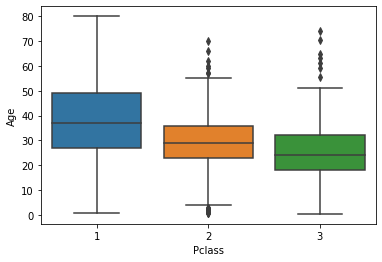

In [40]:
sns.boxplot(data = dataset, y= 'Age', x= 'Pclass' )

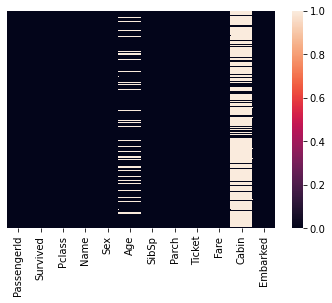

In [41]:
sns.heatmap(dataset.isnull(), yticklabels=False)

In [42]:
dataset.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [43]:
dataset = dataset[['PassengerId','Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked']]

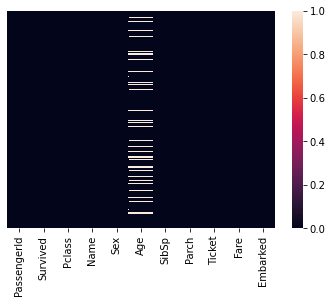

In [44]:
sns.heatmap(dataset.isnull(), yticklabels=False)

In [45]:
model = LinearRegression()

In [46]:
x = dataset[['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Embarked']]

In [47]:
y = dataset['Survived']

In [48]:
def lw(cols):
    age = cols[0]
    Pclass = cols[1]
    if pd.isnull(age):
        if Pclass == 1:
            return 38
        elif Pclass == 2:
            return 30
        elif Pclass == 3:
            return 25
        else:
            return 30
    else:
        return age
    

In [49]:
x['Age'] = dataset[['Age', 'Pclass']].apply(lw , axis=1)

C:\Users\Manjunath D\anaconda3\envs\tf\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


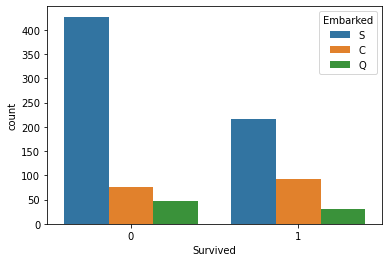

In [50]:
sns.countplot(dataset['Survived'], hue= 'Embarked', data = dataset, )

In [51]:
emb = pd.get_dummies(dataset['Embarked'], drop_first=True)

In [52]:
x['Embarked'] = emb

C:\Users\Manjunath D\anaconda3\envs\tf\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [53]:
sib = pd.get_dummies(dataset['SibSp'], drop_first=True)

In [54]:
x['SibSp'] = sib

C:\Users\Manjunath D\anaconda3\envs\tf\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [55]:
Pclass = pd.get_dummies(dataset['Pclass'], drop_first=True)

In [56]:
x['Pclass'] = Pclass

C:\Users\Manjunath D\anaconda3\envs\tf\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [57]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [58]:
sex= pd.get_dummies(dataset['Sex'], drop_first=True)

In [59]:
x['Sex'] = sex

C:\Users\Manjunath D\anaconda3\envs\tf\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [60]:
par = pd.get_dummies(dataset['Parch'], drop_first=True)

In [61]:
x['Parch'] = par

C:\Users\Manjunath D\anaconda3\envs\tf\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


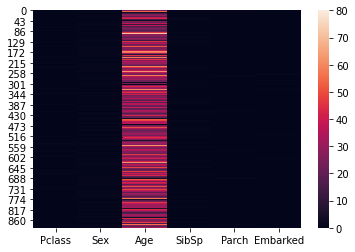

In [62]:
sns.heatmap(x)

,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,1,22.0,1,0,0
1,0,0,38.0,1,0,0
2,0,0,26.0,0,0,0
3,0,0,35.0,1,0,0
4,0,1,35.0,0,0,0
...,...,...,...,...,...,...
886,1,1,27.0,0,0,0
887,0,0,19.0,0,0,0
888,0,0,25.0,1,0,0
889,0,1,26.0,0,0,0


In [64]:
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.15, random_state=42)

In [65]:
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [66]:
y_pred = model.predict(X_test)

In [67]:
y_pred

array([0.29201304, 0.23050599, 0.15151886, 0.8362208 , 0.74226591,
       0.68954359, 0.64478029, 0.14984538, 0.64101495, 0.686615  ,
       0.21637393, 0.16155976, 0.76978478, 0.15570257, 0.23259785,
       0.76601945, 0.21846578, 0.64478029, 0.22883251, 0.16281487,
       0.15319234, 0.15737605, 0.74435776, 0.15151886, 0.15361071,
       0.14733516, 0.15988627, 0.23050599, 0.14482493, 0.69163544,
       0.15110049, 0.68787011, 0.15904953, 0.68912522, 0.15068212,
       0.21219022, 0.15486583, 0.64478029, 0.69121707, 0.15361071,
       0.22632229, 0.21302696, 0.15361071, 0.10926578, 0.7781522 ,
       0.20758815, 0.15110049, 0.15277397, 0.15319234, 0.16741694,
       0.76141737, 0.83882356, 0.21762904, 0.20549629, 0.1260006 ,
       0.68619663, 0.23092436, 0.78024405, 0.76769398, 0.64227006,
       0.15193723, 0.83914939, 0.82250815, 0.15904953, 0.10926578,
       0.77689813, 0.22632229, 0.1552842 , 0.28866608, 0.75816399,
       0.90233098, 0.68619663, 0.15402908, 0.83338474, 0.15277

In [68]:
y_test

709    1
439    0
840    0
720    1
39     1
      ..
494    0
359    1
65     1
481    0
777    1
Name: Survived, Length: 134, dtype: int64

In [70]:
error =  mean_squared_error(y_test, y_pred)

In [71]:
error

0.16989071100855788